In [1]:
import numpy as np
import pandas as pd

Q1. Missing Data Identification

Scenario:
 The hospital suspects incomplete patient records.

Task:

Identify missing values in each column

Calculate percentage of missing data



In [3]:

df = pd.read_csv('healthcare_data_cleaning_dataset.csv')
df

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20
...,...,...,...,...,...,...,...,...,...
5095,11764,NaN,Female,Mumbai,COVID-19,15,NaN,0,2023-09-22
5096,17597,NaN,Female,Chennai,Asthma,2,NaN,0,2023-06-26
5097,19171,NaN,Female,Mumbai,Flu,1,NaN,1,2023-12-31
5098,13854,NaN,Female,Bangalore,Flu,17,NaN,0,2023-01-18


Identify missing values in each column

In [7]:
missing_data_count=df.isna().sum()
print(missing_data_count)

Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64


Calculate percentage of missing data

In [8]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data_count,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

                Missing Count  Missing %
Age                       600      11.76
Treatment_Cost            593      11.63


Q2. Handling Missing Age

Scenario:
 Age is critical for medical analysis, but some values are missing.

Task:

Replace missing Age values with an appropriate method

Justify your choice (mean/median)

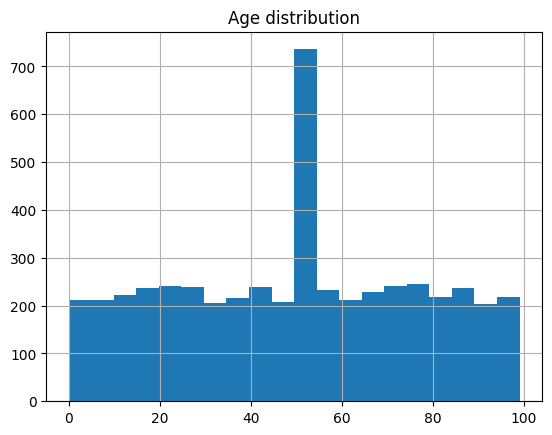

Mean: 49.6378724255149
Median: 50.0


In [22]:
import matplotlib.pyplot as plt
# Check distribution first
df['Age'].hist(bins=20)
plt.title('Age distribution')
plt.show()

# Skewed → use median; symmetric → use mean
print("Mean:", df['Age'].mean())
print("Median:", df['Age'].median())

In [15]:
# Use median (recommended for medical data — robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())



In [16]:
# Verify
print(df['Age'].isnull().sum())  # should be 0

0


Q3. Handling Missing Treatment Cost

Scenario:
 Treatment cost is highly skewed due to expensive treatments.

Task:

Handle missing Treatment_Cost values

Choose the correct imputation method and explain why

In [17]:
import scipy.stats as stats

skew = df['Treatment_Cost'].skew()
print("Skewness:", skew)
# |skew| > 1 → highly skewed → use median

Skewness: 4.485699649227538


In [19]:
# Median is best for skewed financial data
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())
print("Missing after fill:", df['Treatment_Cost'].isnull().sum())
# Reason: median is not affected by extreme high-cost outliers

Missing after fill: 0


Q4. Duplicate Patient Records

Scenario:
 Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after

In [20]:
print("Dataset size before:", df.shape)

# Identify duplicate rows
duplicates = df[df.duplicated()]
print("Duplicate rows found:", len(duplicates))
print(duplicates.head())

Dataset size before: (5100, 9)
Duplicate rows found: 99
      Patient_ID   Age  Gender       City Diagnosis  Hospital_Visits  \
5000       15126  50.0    Male  Hyderabad    Asthma                1   
5001       15108  50.0    Male  Hyderabad    Asthma                3   
5002       10441  50.0    Male    Chennai       Flu                3   
5003       15975  50.0  Female  Hyderabad       Flu               10   
5004       18427  50.0  Female      Delhi  COVID-19               13   

      Treatment_Cost  Insurance_Coverage Admission_Date  
5000         24797.0                   1     2023-01-19  
5001         24797.0                   0     2023-01-27  
5002         24797.0                   0     2023-07-08  
5003         24797.0                   0     2023-06-01  
5004         24797.0                   1     2023-03-04  


In [21]:
df.drop_duplicates(inplace=True)

print("Dataset size after:", df.shape)
print("Rows removed:", len(duplicates))

Dataset size after: (5001, 9)
Rows removed: 99


Q5. Invalid Age Values (Data Quality Check)

Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

Detect such records

Decide whether to remove or correct them



In [23]:
# Detect invalid values
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]
print("Invalid age records:", len(invalid_age))
print(invalid_age[['Age']].head())

Invalid age records: 0
Empty DataFrame
Columns: [Age]
Index: []


In [25]:
# Decision: remove or correct
# Option A — remove invalid rows
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

# Option B — replace with NaN then re-impute
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = None
df['Age']= df['Age'].fillna(df['Age'].median())

print("Cleaned dataset size:", df.shape)

Cleaned dataset size: (5001, 9)


Q6. Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers

In [26]:
# IQR method
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Treatment_Cost'] < lower) |
              (df['Treatment_Cost'] > upper)]

print("Outliers detected:", len(outliers))
print("Lower bound:", lower)
print("Upper bound:", upper)

Outliers detected: 50
Lower bound: -20398.0
Upper bound: 70706.0


Q7. Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile

In [29]:
#Apply capping at 5th and 95th percentile
per5  = df['Treatment_Cost'].quantile(0.05)
per95 = df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost_Capped'] = df['Treatment_Cost'].clip(
    lower=per5, upper=per95
)

print("Original range:", df['Treatment_Cost'].min(),
      "->", df['Treatment_Cost'].max())
print("Capped range  :", df['Treatment_Cost_Capped'].min(),
      "->", df['Treatment_Cost_Capped'].max())

Original range: 526.0 -> 199702.96533333333
Capped range  : 3238.0 -> 47948.0


Q8. Transformation
Scenario:
 Treatment cost is highly skewed.
Task:
Apply log transformation
Create a new column
Compare before vs after distribution

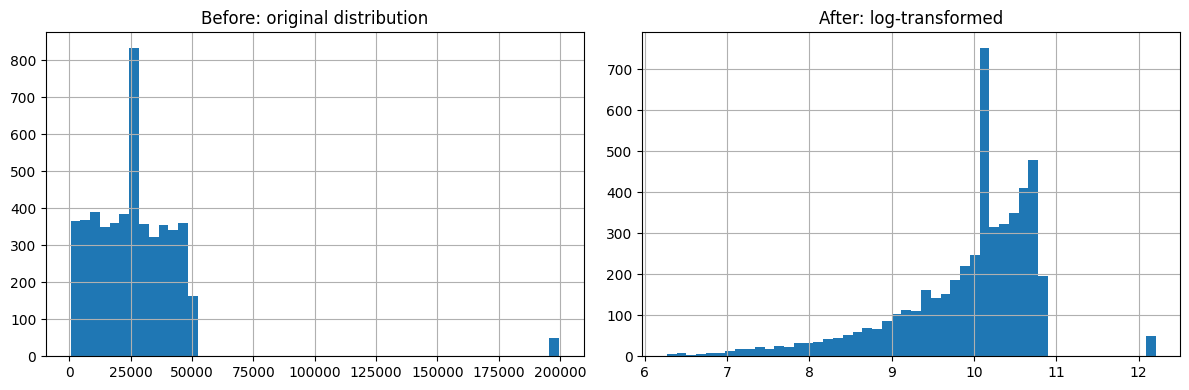

Skew before: 4.75
Skew after : -1.23


In [30]:
# Apply log transform and compare distributions
df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Treatment_Cost'].hist(bins=50, ax=axes[0])
axes[0].set_title('Before: original distribution')
df['Treatment_Cost_Log'].hist(bins=50, ax=axes[1])
axes[1].set_title('After: log-transformed')
plt.tight_layout()
plt.show()
print("Skew before:", df['Treatment_Cost'].skew().round(2))
print("Skew after :", df['Treatment_Cost_Log'].skew().round(2))

Q9. Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice

In [35]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Sort by date before filling
df = df.sort_values('Admission_Date')
df = df.reset_index(drop=True)

# Forward fill — propagates last known date forward
df['Admission_Date'] = df['Admission_Date'].ffill()

# Backward fill for leading NaNs at the start
df['Admission_Date'] = df['Admission_Date'].bfill()

print(df['Admission_Date'].isnull().sum())

5001
